# Análisis léxico para MiniTcl
## De expresiones regulares a ε-NFA, de ε-NFA a DFA y del DFA a un lexer en Python

**Propósito.** Construir, paso a paso, el analizador léxico de un subconjunto educativo de Tcl llamado **MiniTcl**. Al finalizar podrá:

1. distinguir lexemas, tokens y valores semánticos;
2. especificar tokens mediante expresiones regulares;
3. construir un ε-NFA con el algoritmo de Thompson;
4. convertir el ε-NFA en un DFA mediante construcción por subconjuntos;
5. aplicar las reglas de **máximo consumo** y **prioridad**;
6. usar el DFA como base de un lexer real en Python.

> En Tcl, el análisis completo de una orden depende del contexto (sustituciones, comillas, llaves y corchetes). Este cuaderno usa deliberadamente un **subconjunto MiniTcl** para aislar y estudiar la fase léxica.

## 1. Del programa fuente a los tokens

El lexer recibe caracteres y produce unidades que el parser puede consumir:

$$\text{caracteres} \longrightarrow \text{lexer} \longrightarrow \text{tokens}$$

Cada token suele tener:

- **tipo**: `SET`, `ID`, `NUMBER`, `STRING`, etc.;
- **lexema**: los caracteres originales, por ejemplo `42`;
- **valor semántico**: una representación útil, por ejemplo el entero `42`;
- **posición**: línea y columna, indispensable para informar errores.

Ejemplo MiniTcl:

```tcl
set radio 5
set area [expr 3.1416 * $radio * $radio]
puts "Área = $area"
```

Una primera secuencia aproximada sería:

```text
SET ID NUMBER NEWLINE
SET ID LBRACKET EXPR NUMBER STAR VARIABLE STAR VARIABLE RBRACKET NEWLINE
PUTS STRING
```

In [22]:
from dataclasses import dataclass

@dataclass(frozen=True)
class Token:
    type: str
    lexeme: str
    value: object
    line: int
    column: int

Token("NUMBER", "42", 42, 1, 11)

Token(type='NUMBER', lexeme='42', value=42, line=1, column=11)

### Actividad 1 — Tokenización manual

Sin ejecutar código, proponga los tokens de:

```tcl
set n 10
if {$n >= 2} { puts "grande" }
```

Preguntas:

1. ¿`if` debe ser `ID` o palabra reservada?
2. ¿`>=` debe producir un token o dos?
3. ¿Conviene descartar el salto de línea en MiniTcl?

   RESPUESTAS
   1. if debe ser una palabra reservada
   2. >= o <= debe producir un solo token
   3. No una string puede contener un salto de linea que afecte a la salida por consola

<details><summary>Orientación</summary>

`if` debe reconocerse como palabra reservada; `>=` exige máximo consumo; en Tcl el salto de línea puede terminar una orden, por lo que aquí se conserva como `NEWLINE`.
</details>

## 2. Expresiones regulares (ER)

Una ER $M$ describe un lenguaje $L(M)$, es decir, un conjunto de cadenas. Sus constructores fundamentales son:

| ER | Significado |
|---|---|
| $a$ | el símbolo `a` |
| $\varepsilon$ | cadena vacía |
| $M\mid N$ | alternancia |
| $MN$ | concatenación |
| $M^*$ | cero o más repeticiones |
| $M^+$ | una o más repeticiones |
| $M?$ | cero o una aparición |

Abreviaturas habituales: `[a-z]`, `[0-9]`, `\s`, `.`. En este cuaderno construiremos autómatas desde la sintaxis formal `|`, concatenación, `*`, `+`, `?` y paréntesis; las clases se expanden antes de entrar al constructor.

### Especificación léxica de MiniTcl

| Token | ER práctica de Python | Ejemplo |
|---|---|---|
| `NUMBER` | `\d+(\.\d+)?` | `12`, `3.14` |
| `VARIABLE` | `\$[A-Za-z_][A-Za-z0-9_]*` | `$radio` |
| `ID` | `[A-Za-z_][A-Za-z0-9_]*` | `radio` |
| `STRING` | `"([^"\\]|\\.)*"` | `"hola\n"` |
| `GE` | `>=` | `>=` |
| `GT` | `>` | `>` |
| `COMMENT` | `\#[^\n]*` | `# comentario` |

Las palabras `set`, `puts`, `expr`, `if` y `else` tienen la misma forma que `ID`. Podemos darles prioridad mediante reglas anteriores o reconocer primero `ID` y reclasificar después.

In [23]:
import re
import ast

patrones_minitcl = {
    "NUMBER":   r"\d+(?:\.\d+)?",
    "VARIABLE": r"\$[A-Za-z_][A-Za-z0-9_]*",
    "ID":       r"[A-Za-z_][A-Za-z0-9_]*",
    "STRING":   r'"(?:[^"\\]|\\.)*"',
    "GE":       r">=",
    "GT":       r">",
    "COMMENT":  r"\#[^\n]*",
}

pruebas = ["12", "3.14", "$radio", "nombre_2", '"hola\\n"', ">=", ">", "# Esto es comentario"]
for texto in pruebas:
    aceptan = [nombre for nombre, patron in patrones_minitcl.items()
               if re.fullmatch(patron, texto)]
    print(f"{texto!r:12} -> {aceptan}")

'12'         -> ['NUMBER']
'3.14'       -> ['NUMBER']
'$radio'     -> ['VARIABLE']
'nombre_2'   -> ['ID']
'"hola\\n"'  -> ['STRING']
'>='         -> ['GE']
'>'          -> ['GT']
'# Esto es comentario' -> ['COMMENT']


### Actividad 2 — Diseñar ER

Escriba ER para:

1. enteros con signo opcional;
2. nombres de variable MiniTcl que comiencen por `$`;
3. operadores `==`, `!=`, `<=`, `>=`, `<`, `>`;
4. comentarios que comienzan con `#` y terminan antes del salto de línea.
   RESPUESTAS
   1. [+-]?[0-9]+
   2. \$[a-zA-Z_][a-zA-Z0-9_]*
   3. ==|!=|<=|>=|<|>
   4. #[^\n]*

Compruebe las ER con `re.fullmatch`. Incluya al menos dos casos válidos y dos inválidos por regla.
CASOS VALIDOS
1. +9, -234546542
2. $_HOLA_MUNDO, $compilers
3. ==, !=
4. #este es un comentario, #este es otro comentario
CASOS INVALIDOS
1. 3.14, 14.3
2. _HOLA_MUNDO, compilers
3. =>, =<
4. este no es un comentario, este tampoco es un comentario

## 3. De una ER a un ε-NFA: construcción de Thompson

Un **NFA** puede tener varias transiciones con la misma etiqueta y transiciones $\varepsilon$, que no consumen entrada. Thompson construye fragmentos con un único inicio y un único final:

- símbolo: una transición etiquetada;
- concatenación: conecta el final izquierdo al inicio derecho con $\varepsilon$;
- alternancia: crea bifurcación y reunión mediante $\varepsilon$;
- estrella: permite entrar, repetir o salir mediante $\varepsilon$.

Usaremos una representación explícita. Para que el algoritmo sea visible, el parser acepta símbolos individuales, `ε`, `|`, `*`, `+`, `?` y paréntesis. La concatenación se inserta como el operador interno `·`.

In [24]:
from collections import defaultdict
from dataclasses import dataclass, field
from itertools import count

EPS = "ε"

@dataclass
class NFA:
    start: int
    accept: int
    transitions: dict = field(default_factory=lambda: defaultdict(lambda: defaultdict(set)))

    @property
    def states(self):
        result = {self.start, self.accept}
        for source, edges in self.transitions.items():
            result.add(source)
            for targets in edges.values():
                result.update(targets)
        return result

def add_edge(nfa, source, symbol, target):
    nfa.transitions[source][symbol].add(target)

def merge_edges(target, source):
    for state, edges in source.transitions.items():
        for symbol, destinations in edges.items():
            target.transitions[state][symbol].update(destinations)

In [25]:
def tokenize_regex(regex):
    # Convierte la ER formal en símbolos; la barra protege metacaracteres.
    tokens, i = [], 0
    while i < len(regex):
        if regex[i] == "\\":
            if i + 1 == len(regex):
                raise ValueError("Barra invertida sin símbolo")
            tokens.append(("LIT", regex[i + 1]))
            i += 2
        elif regex[i] in "()|*+?":
            tokens.append((regex[i], regex[i]))
            i += 1
        elif regex[i].isspace():
            i += 1
        else:
            tokens.append(("EPS", EPS) if regex[i] == EPS else ("LIT", regex[i]))
            i += 1
    return tokens

def add_concat(tokens):
    result = []
    can_end = {"LIT", "EPS", ")", "*", "+", "?"}
    can_start = {"LIT", "EPS", "("}
    for token in tokens:
        if result and result[-1][0] in can_end and token[0] in can_start:
            result.append(("CONCAT", "·"))
        result.append(token)
    return result

def to_postfix(regex):
    # Shunting-yard: ER infija -> notación postfija.
    precedence = {"|": 1, "CONCAT": 2}
    output, stack = [], []
    for kind, value in add_concat(tokenize_regex(regex)):
        if kind in {"LIT", "EPS"}:
            output.append((kind, value))
        elif kind in {"*", "+", "?"}:
            output.append((kind, value))  # operadores postfijos
        elif kind == "(":
            stack.append((kind, value))
        elif kind == ")":
            while stack and stack[-1][0] != "(":
                output.append(stack.pop())
            if not stack:
                raise ValueError("Paréntesis no balanceados")
            stack.pop()
        else:
            while stack and stack[-1][0] != "(" and precedence[stack[-1][0]] >= precedence[kind]:
                output.append(stack.pop())
            stack.append((kind, value))
    while stack:
        if stack[-1][0] == "(":
            raise ValueError("Paréntesis no balanceados")
        output.append(stack.pop())
    return output

print(to_postfix("a(b|c)*"))

[('LIT', 'a'), ('LIT', 'b'), ('LIT', 'c'), ('|', '|'), ('*', '*'), ('CONCAT', '·')]


In [26]:
def regex_to_nfa(regex):
    ids = count()
    stack = []

    def basic(symbol):
        s, t = next(ids), next(ids)
        nfa = NFA(s, t)
        add_edge(nfa, s, symbol, t)
        return nfa

    for kind, value in to_postfix(regex):
        if kind in {"LIT", "EPS"}:
            stack.append(basic(value))
        elif kind == "CONCAT":
            b, a = stack.pop(), stack.pop()
            nfa = NFA(a.start, b.accept)
            merge_edges(nfa, a); merge_edges(nfa, b)
            add_edge(nfa, a.accept, EPS, b.start)
            stack.append(nfa)
        elif kind == "|":
            b, a = stack.pop(), stack.pop()
            s, t = next(ids), next(ids)
            nfa = NFA(s, t)
            merge_edges(nfa, a); merge_edges(nfa, b)
            for start in (a.start, b.start): add_edge(nfa, s, EPS, start)
            for end in (a.accept, b.accept): add_edge(nfa, end, EPS, t)
            stack.append(nfa)
        elif kind == "*":
            a = stack.pop(); s, t = next(ids), next(ids)
            nfa = NFA(s, t); merge_edges(nfa, a)
            add_edge(nfa, s, EPS, a.start); add_edge(nfa, s, EPS, t)
            add_edge(nfa, a.accept, EPS, a.start); add_edge(nfa, a.accept, EPS, t)
            stack.append(nfa)
        elif kind == "+":
            a = stack.pop(); s, t = next(ids), next(ids)
            nfa = NFA(s, t); merge_edges(nfa, a)
            add_edge(nfa, s, EPS, a.start)
            add_edge(nfa, a.accept, EPS, a.start); add_edge(nfa, a.accept, EPS, t)
            stack.append(nfa)
        elif kind == "?":
            a = stack.pop(); s, t = next(ids), next(ids)
            nfa = NFA(s, t); merge_edges(nfa, a)
            add_edge(nfa, s, EPS, a.start); add_edge(nfa, s, EPS, t)
            add_edge(nfa, a.accept, EPS, t)
            stack.append(nfa)
    if len(stack) != 1:
        raise ValueError("Expresión regular incompleta")
    return stack[0]

nfa_demo = regex_to_nfa("a(b|c)*")
print("Estados:", sorted(nfa_demo.states))
print("Inicio/final:", nfa_demo.start, nfa_demo.accept)

Estados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Inicio/final: 0 9


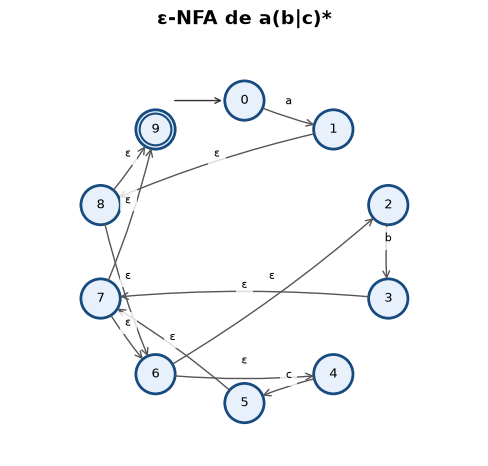

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import math

def draw_automaton(states, transitions, start, accepts, title="Autómata"):
    states = sorted(states, key=str)
    n = len(states)
    angles = [math.pi/2 - 2*math.pi*i/max(n, 1) for i in range(n)]
    pos = {s: (math.cos(a), math.sin(a)) for s, a in zip(states, angles)}
    fig, ax = plt.subplots(figsize=(max(7, n*0.65), 5.5))
    ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title, fontsize=14, weight="bold")
    for s, (x, y) in pos.items():
        ax.add_patch(Circle((x, y), .13, facecolor="#e8f1fb", edgecolor="#174a7e", lw=2))
        if s in accepts:
            ax.add_patch(Circle((x, y), .105, fill=False, edgecolor="#174a7e", lw=1.5))
        ax.text(x, y, str(s), ha="center", va="center", fontsize=9)
    sx, sy = pos[start]
    ax.annotate("", xy=(sx-.13, sy), xytext=(sx-.48, sy),
                arrowprops=dict(arrowstyle="->", color="#333"))
    grouped = defaultdict(list)
    for source, edges in transitions.items():
        for symbol, targets in edges.items():
            for target in targets:
                grouped[(source, target)].append(symbol)
    for (source, target), labels in grouped.items():
        x1, y1 = pos[source]; x2, y2 = pos[target]
        if source == target:
            arrow = FancyArrowPatch((x1-.05, y1+.12), (x1+.05, y1+.12),
                                    connectionstyle="arc3,rad=-1.8", arrowstyle="->",
                                    mutation_scale=12, color="#555")
            lx, ly = x1, y1+.36
        else:
            rad = .16 if (target, source) in grouped else .05
            arrow = FancyArrowPatch((x1, y1), (x2, y2), connectionstyle=f"arc3,rad={rad}",
                                    arrowstyle="->", mutation_scale=12, shrinkA=14,
                                    shrinkB=14, color="#555")
            lx, ly = (x1+x2)/2, (y1+y2)/2 + .09
        ax.add_patch(arrow)
        ax.text(lx, ly, ",".join(sorted(labels)), ha="center", va="center",
                fontsize=8, bbox=dict(facecolor="white", edgecolor="none", alpha=.8))
    ax.set_xlim(-1.55, 1.55); ax.set_ylim(-1.35, 1.45)
    plt.show()

draw_automaton(nfa_demo.states, nfa_demo.transitions, nfa_demo.start,
               {nfa_demo.accept}, "ε-NFA de a(b|c)*")

### Actividad 3 — Thompson a mano y en Python

1. Dibuje los fragmentos de Thompson para `a`, `ab`, `a|b` y `a*`.
2. Prediga cuántos estados crea `regex_to_nfa("ab*")`.
3. Construya y visualice los NFA de `(a|b)*abb` y `\$i(d|x)*`.
4. Explique por qué las transiciones $\varepsilon$ simplifican la composición.

{0, 1}
0
1


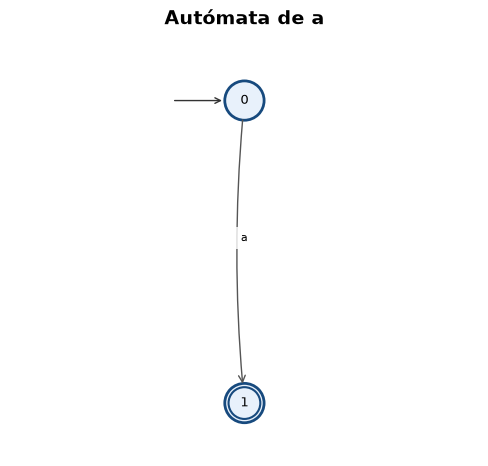

In [28]:
first_nfa = regex_to_nfa("a")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de a")


{0, 1, 2, 3}
0
3


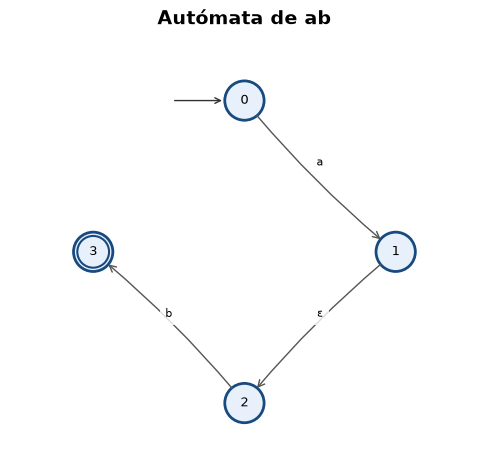

In [29]:
first_nfa = regex_to_nfa("ab")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de ab")

{0, 1, 2, 3, 4, 5}
4
5


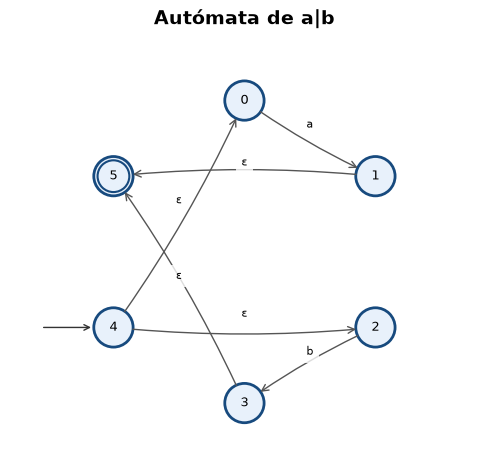

In [30]:
first_nfa = regex_to_nfa("a|b")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de a|b")

{0, 1, 2, 3}
2
3


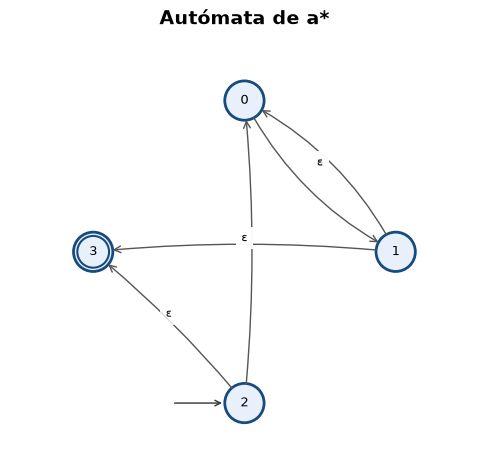

In [31]:
first_nfa = regex_to_nfa("a*")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de a*")

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13}
6
13


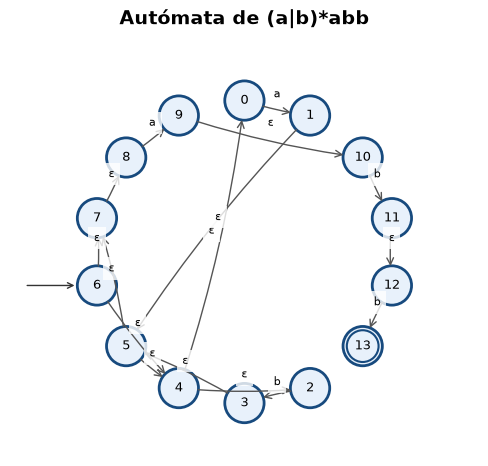

In [32]:
first_nfa = regex_to_nfa("(a|b)*abb")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de (a|b)*abb")

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
0
11


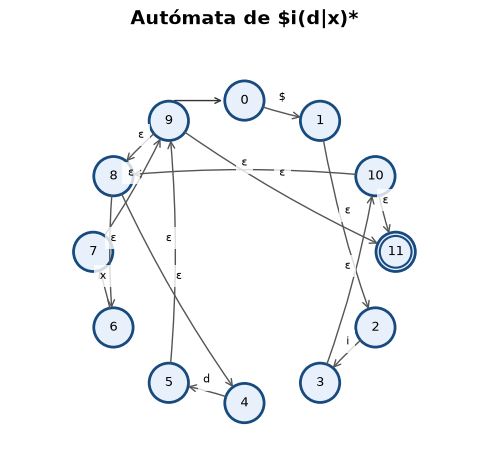

In [33]:
first_nfa = regex_to_nfa("\$i(d|x)*")
print(first_nfa.states)
print(first_nfa.start)
print(first_nfa.accept)
draw_automaton(first_nfa.states, first_nfa.transitions, first_nfa.start, {first_nfa.accept}, "Autómata de \$i(d|x)*")

## 4. Simulación del NFA y clausura-ε

La **clausura-ε** de un conjunto $S$ contiene los estados alcanzables desde $S$ usando cero o más transiciones $\varepsilon$.

Para consumir un símbolo $c$:

$$\operatorname{move}(S,c)=\bigcup_{s\in S}\operatorname{edge}(s,c)$$

$$\operatorname{next}(S,c)=\varepsilon\text{-closure}(\operatorname{move}(S,c))$$

In [34]:
def epsilon_closure(nfa, states):
    closure = set(states)
    pending = list(states)
    while pending:
        state = pending.pop()
        for target in nfa.transitions[state].get(EPS, set()):
            if target not in closure:
                closure.add(target)
                pending.append(target)
    return frozenset(closure)

def move(nfa, states, symbol):
    reached = set()
    for state in states:
        reached.update(nfa.transitions[state].get(symbol, set()))
    return reached

def nfa_accepts(nfa, text, trace=False):
    current = epsilon_closure(nfa, {nfa.start})
    if trace: print("inicio:", sorted(current))
    for char in text:
        current = epsilon_closure(nfa, move(nfa, current, char))
        if trace: print(f"lee {char!r}:", sorted(current))
    return nfa.accept in current

for sample in ["a", "ab", "acbc", "", "ad"]:
    print(f"{sample!r:6} -> {nfa_accepts(nfa_demo, sample)}")

print("\nTraza para 'acbc':")
nfa_accepts(nfa_demo, "acbc", trace=True)

'a'    -> True
'ab'   -> True
'acbc' -> True
''     -> False
'ad'   -> False

Traza para 'acbc':
inicio: [0]
lee 'a': [1, 2, 4, 6, 8, 9]
lee 'c': [2, 4, 5, 6, 7, 9]
lee 'b': [2, 3, 4, 6, 7, 9]
lee 'c': [2, 4, 5, 6, 7, 9]


True

## 5. De NFA a DFA: construcción por subconjuntos

Elimina la necesidad de “adivinar”: cada estado del DFA representa un **conjunto de estados del NFA**.

1. Estado inicial: $\varepsilon$-closure del inicio del NFA.
2. Para cada conjunto $D$ y símbolo $c$, calcule `ε-closure(move(D,c))`.
3. Si el conjunto resultante es nuevo, agréguelo como estado del DFA.
4. Un estado DFA es final si contiene el estado final del NFA.

En el peor caso un NFA de $n$ estados puede producir hasta $2^n$ conjuntos, aunque normalmente solo se materializan los alcanzables.

In [35]:
@dataclass
class DFA:
    start: int
    accepts: set
    transitions: dict
    subsets: dict
    alphabet: tuple

def nfa_to_dfa(nfa):
    alphabet = sorted({symbol for edges in nfa.transitions.values()
                       for symbol in edges if symbol != EPS})
    start_set = epsilon_closure(nfa, {nfa.start})
    subset_id = {start_set: 0}
    subsets = {0: start_set}
    pending = [start_set]
    transitions = defaultdict(lambda: defaultdict(set))

    while pending:
        current = pending.pop(0)
        source_id = subset_id[current]
        for symbol in alphabet:
            target = epsilon_closure(nfa, move(nfa, current, symbol))
            if not target:
                continue
            if target not in subset_id:
                new_id = len(subset_id)
                subset_id[target] = new_id
                subsets[new_id] = target
                pending.append(target)
            transitions[source_id][symbol].add(subset_id[target])

    accepts = {sid for sid, subset in subsets.items() if nfa.accept in subset}
    return DFA(0, accepts, transitions, subsets, tuple(alphabet))

dfa_demo = nfa_to_dfa(nfa_demo)
for sid, subset in dfa_demo.subsets.items():
    print(f"D{sid} = {sorted(subset)}", "(final)" if sid in dfa_demo.accepts else "")

D0 = [0] 
D1 = [1, 2, 4, 6, 8, 9] (final)
D2 = [2, 3, 4, 6, 7, 9] (final)
D3 = [2, 4, 5, 6, 7, 9] (final)


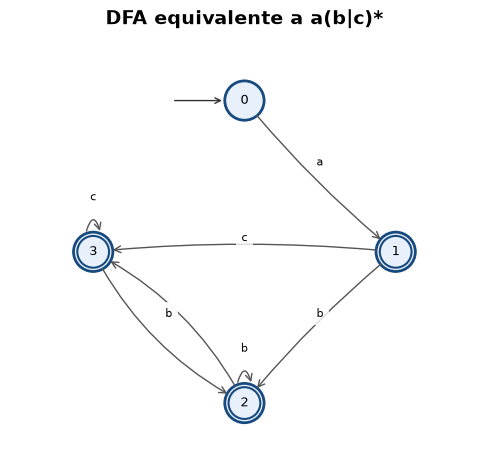

'a' True True
'ab' True True
'acbc' True True
'' False False
'ad' False False
'abcccb' True True


In [36]:
draw_automaton(dfa_demo.subsets.keys(), dfa_demo.transitions, dfa_demo.start,
               dfa_demo.accepts, "DFA equivalente a a(b|c)*")

def dfa_accepts(dfa, text):
    state = dfa.start
    for char in text:
        targets = dfa.transitions.get(state, {}).get(char, set())
        if not targets:
            return False
        state = next(iter(targets))
    return state in dfa.accepts

samples = ["a", "ab", "acbc", "", "ad", "abcccb"]
for sample in samples:
    print(repr(sample), nfa_accepts(nfa_demo, sample), dfa_accepts(dfa_demo, sample))

### Actividad 4 — Construcción por subconjuntos

Para la ER `(a|b)*abb`:

1. calcule manualmente al menos los tres primeros estados-conjunto;
2. construya el DFA con el código;
3. verifique `abb`, `aabb`, `babb`, `ababa`;
4. compare la cantidad de estados del NFA y del DFA;
5. describa cómo detectaría estados DFA equivalentes para minimizarlos.

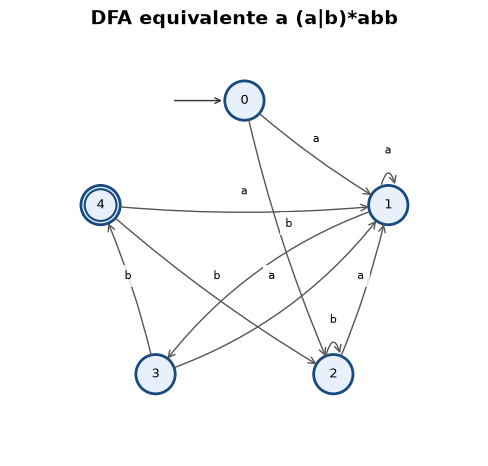

In [42]:
nfa = regex_to_nfa("(a|b)*abb")
dfa = nfa_to_dfa(nfa)
draw_automaton(dfa.subsets.keys(), dfa.transitions, dfa.start, dfa.accepts, "DFA equivalente a (a|b)*abb")

## 6. Del DFA al lexer: máximo consumo y prioridad

Un lexer combina varias reglas. Surgen dos ambigüedades clásicas:

- **Máximo consumo (maximal munch):** para `>=`, no se entrega `>` si todavía puede aceptarse `=`.
- **Prioridad:** si `if` coincide tanto con `IF` como con `ID`, gana la regla definida primero.

El siguiente lexer práctico usa las ER del módulo `re`, pero implementa explícitamente ambas decisiones. Conceptualmente, un generador de lexers compila todas las ER a un NFA combinado, lo convierte a DFA y marca cada estado final con la regla prioritaria.

In [38]:
RULES = [
    ("WHITESPACE", r"[ \t\r]+"),
    ("COMMENT",    r"\#[^\n]*"),
    ("NEWLINE",    r"\n"),
    ("STRING",     r'"(?:[^"\\]|\\.)*"'),
    ("NUMBER",     r"\d+(?:\.\d+)?"),
    ("VARIABLE",   r"\$[A-Za-z_][A-Za-z0-9_]*"),
    ("ID",         r"[A-Za-z_][A-Za-z0-9_]*"),
    ("GE",         r">="), ("LE", r"<="), ("EQ", r"=="), ("NE", r"!="),
    ("GT",         r">"),  ("LT", r"<"),  ("ASSIGN", r"="),
    ("PLUS",       r"\+"), ("MINUS", r"-"), ("STAR", r"\*"), ("SLASH", r"/"),
    ("LBRACKET",   r"\["), ("RBRACKET", r"\]"),
    ("LBRACE",     r"\{"), ("RBRACE", r"\}"),
    ("LPAREN",     r"\("), ("RPAREN", r"\)"), ("SEMICOLON", r";"),
]

KEYWORDS = {"set": "SET", "puts": "PUTS", "expr": "EXPR",
            "if": "IF", "else": "ELSE", "while": "WHILE"}
SKIP = {"WHITESPACE", "COMMENT"}
COMPILED_RULES = [(name, re.compile(pattern)) for name, pattern in RULES]

class LexerError(Exception):
    pass

def semantic_value(kind, lexeme):
    if kind == "NUMBER":
        return float(lexeme) if "." in lexeme else int(lexeme)
    if kind == "VARIABLE":
        return lexeme[1:]
    if kind == "STRING":
        # literal_eval interpreta escapes sin corromper caracteres Unicode.
        return ast.literal_eval(lexeme)
    return lexeme

def lex(source):
    tokens, pos, line, column = [], 0, 1, 1
    while pos < len(source):
        candidates = []
        for priority, (kind, pattern) in enumerate(COMPILED_RULES):
            match = pattern.match(source, pos)
            if match:
                candidates.append((len(match.group()), -priority, kind, match.group()))
        if not candidates:
            raise LexerError(f"Carácter inesperado {source[pos]!r} en {line}:{column}")
        _, _, kind, lexeme = max(candidates)  # longitud; luego regla anterior
        if kind == "ID":
            kind = KEYWORDS.get(lexeme, "ID")
        if kind not in SKIP:
            tokens.append(Token(kind, lexeme, semantic_value(kind, lexeme), line, column))
        for char in lexeme:
            if char == "\n": line, column = line + 1, 1
            else: column += 1
        pos += len(lexeme)
    return tokens

In [39]:
programa = '''# área de un círculo
set radio 5
set area [expr 3.1416 * $radio * $radio]
if {$area >= 50} { puts "Área grande" }
'''

tokens = lex(programa)
for token in tokens:
    print(f"{token.line:>2}:{token.column:<2} {token.type:<10} "
          f"lexema={token.lexeme!r:<14} valor={token.value!r}")

 1:21 NEWLINE    lexema='\n'           valor='\n'
 2:1  SET        lexema='set'          valor='set'
 2:5  ID         lexema='radio'        valor='radio'
 2:11 NUMBER     lexema='5'            valor=5
 2:12 NEWLINE    lexema='\n'           valor='\n'
 3:1  SET        lexema='set'          valor='set'
 3:5  ID         lexema='area'         valor='area'
 3:10 LBRACKET   lexema='['            valor='['
 3:11 EXPR       lexema='expr'         valor='expr'
 3:16 NUMBER     lexema='3.1416'       valor=3.1416
 3:23 STAR       lexema='*'            valor='*'
 3:25 VARIABLE   lexema='$radio'       valor='radio'
 3:32 STAR       lexema='*'            valor='*'
 3:34 VARIABLE   lexema='$radio'       valor='radio'
 3:40 RBRACKET   lexema=']'            valor=']'
 3:41 NEWLINE    lexema='\n'           valor='\n'
 4:1  IF         lexema='if'           valor='if'
 4:4  LBRACE     lexema='{'            valor='{'
 4:5  VARIABLE   lexema='$area'        valor='area'
 4:11 GE         lexema='>='           

### Experimento — ¿Cómo decide el lexer?

Prediga y luego ejecute:

```python
for texto in [">=", ">", "if", "if2", "$if", "12.5", "12."]:
    try:
        print(texto, lex(texto))
    except LexerError as error:
        print(texto, error)
```

Observe que `12.` se divide como `NUMBER('12')` seguido de un error por `.`. Si MiniTcl aceptara ese formato, habría que cambiar su especificación.

In [40]:
for texto in [">=", ">", "if", "if2", "$if", "12.5", "12."]:
    try:
        print(texto, lex(texto))
    except LexerError as error:
        print(texto, error)

>= [Token(type='GE', lexeme='>=', value='>=', line=1, column=1)]
> [Token(type='GT', lexeme='>', value='>', line=1, column=1)]
if [Token(type='IF', lexeme='if', value='if', line=1, column=1)]
if2 [Token(type='ID', lexeme='if2', value='if2', line=1, column=1)]
$if [Token(type='VARIABLE', lexeme='$if', value='if', line=1, column=1)]
12.5 [Token(type='NUMBER', lexeme='12.5', value=12.5, line=1, column=1)]
12. Carácter inesperado '.' en 1:3


## 7. Pruebas del lexer

Las pruebas convierten la especificación en un contrato verificable.

In [41]:
def token_types(source):
    return [token.type for token in lex(source)]

assert token_types("set x 10") == ["SET", "ID", "NUMBER"]
assert token_types("if if2") == ["IF", "ID"]
assert token_types("$x >= 2") == ["VARIABLE", "GE", "NUMBER"]
assert token_types("puts \"hola\"") == ["PUTS", "STRING"]
assert token_types("# ignorar\nset x 1") == ["NEWLINE", "SET", "ID", "NUMBER"]
assert lex("set x 3.5")[-1].value == 3.5
print("Todas las pruebas pasaron.")

Todas las pruebas pasaron.


## 8. Laboratorio integrador

Extienda el lexer para aceptar:

1. booleanos `true` y `false` con valor semántico Python;
2. el operador lógico `&&`;
3. variables con nombres de espacio Tcl, por ejemplo `$math::pi`;
4. continuación de línea mediante `\\\n`;
5. mensajes de error que muestren la línea fuente y un indicador `^`.

### Casos obligatorios

```tcl
set activo true
if {$activo && $math::pi >= 3.14} {
    puts "válido"
}
```

Escriba por lo menos ocho `assert`: cuatro casos válidos, dos casos de máximo consumo, uno de prioridad y uno de error.

### Preguntas de reflexión

1. ¿Qué información debe llegar al parser además del tipo de token?
2. ¿Por qué un DFA no necesita retroceder dentro de una coincidencia, pero el lexer sí recuerda el último estado final?
3. ¿Qué cambia si dos reglas aceptan el mismo lexema y tienen la misma longitud?
4. ¿Qué elementos reales de Tcl requieren más que expresiones regulares aisladas?

## 9. Reto avanzado — Unir varias reglas en un solo NFA

Implemente el esquema de un generador de lexer:

1. construya un NFA por cada ER;
2. cree un nuevo estado inicial con transiciones $\varepsilon$ a cada NFA;
3. etiquete cada estado final con `(tipo_token, prioridad)`;
4. aplique construcción por subconjuntos;
5. si un conjunto contiene varios finales, seleccione la prioridad menor;
6. simule el DFA recordando el último estado final y la posición correspondiente.

**Meta:** reemplazar `re.compile` en `lex` por su propio DFA. Empiece con `IF = if`, `ID = (i|f|x)(i|f|x)*` y `NUMBER = (0|1)(0|1)*`, y después amplíe el alfabeto.

## 10. Síntesis

```text
ER de cada token
      ↓ Thompson
ε-NFA individuales
      ↓ nuevo inicio + ε
NFA combinado
      ↓ clausura-ε + construcción por subconjuntos
DFA con finales etiquetados
      ↓ máximo consumo + prioridad
Lexer: caracteres → tokens
```

La idea central es separar **especificación** y **ejecución**: las ER expresan qué lexemas son válidos; Thompson aporta una construcción mecánica; el DFA ofrece una ejecución eficiente; y las reglas de máximo consumo y prioridad resuelven las ambigüedades propias de un lexer.

### Referencia base

Torsten Grust, *Compiler Construction — 2. Lexical Analysis*, diapositivas de la Universidad de Konstanz, curso 2002/03, pp. 45–73. Adaptación pedagógica al subconjunto MiniTcl y código Python elaborados para este cuaderno.